# COMP3008 Big Data Analytics — Assessment 2
## How has COVID-19 impacted employment patterns and regional economies in the UK?
**Data source:** UK Annual Population Survey (APS), January 2019 – December 2024  
**Module:** COMP3008 | University of Plymouth

---

### How this notebook is organised
| Section | Purpose | Report section it feeds |
|---|---|---|
| 1. Setup | Imports and paths | — |
| 2. Load & Merge | Read both CSVs, combine into one DataFrame | Pre-processing |
| 3. Pre-processing | Column harmonisation, type fixing, missingness | Pre-processing |
| 4. EDA — Method 1 | Descriptive statistics & distributions | Application of Methods |
| 5. EDA — Method 2 | Labour-status time-series trend (2019–2024) | Application of Methods |
| 6. EDA — Method 3 | Regional comparison (employment rate by Government Office Region) | Application of Methods |
| 7. EDA — Method 4 | K-Means clustering of worker profiles | Application of Methods |
| 8. Predictive — ARIMA | Time-series forecast of annual employment rate | Application of Methods |
| 9. Predictive — Ridge | Linear regression of gross weekly pay | Application of Methods |
| 10. Predictive — RF | Random Forest regression of gross weekly pay | Application of Methods |
| 11. Model Comparison | Metrics table and suitability commentary | Results |

> **AI declaration:** Sections of this code were drafted with assistance from GitHub Copilot and Claude (A7 — code generation for learning purposes). All code has been reviewed, understood, and adapted by the student.

---
## Section 1 — Setup
Install any missing packages and import everything the notebook needs.  
Run this cell first every time.

In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn pmdarima --quiet

# ── Standard library ──────────────────────────────────────────────────────────
import warnings
from pathlib import Path

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ── Time-series ───────────────────────────────────────────────────────────────
# pmdarima gives us auto_arima which selects the best ARIMA order automatically.
# Install with: pip install pmdarima
try:
    from pmdarima import auto_arima
    ARIMA_AVAILABLE = True
except ImportError:
    print("pmdarima not found. Run: pip install pmdarima")
    ARIMA_AVAILABLE = False

warnings.filterwarnings("ignore")   # suppress minor sklearn/statsmodels warnings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130    # legible at 100% zoom as required by brief

# ── Paths ─────────────────────────────────────────────────────────────────────
# All paths are relative to this notebook's location — no hard-coded drives.
NOTEBOOK_DIR = Path().resolve()                      # wherever the notebook lives
DATA_DIR     = NOTEBOOK_DIR / "Report_Data"          # both CSVs sit here
OUT_DIR      = NOTEBOOK_DIR / "analysis_outputs"     # figures and CSVs written here
FIG_DIR      = OUT_DIR / "figures"                   # all saved figures

OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

FILE_A = DATA_DIR / "AnnualPopulationSurvey_Jan2019_Dec2021.csv"
FILE_B = DATA_DIR / "AnnualPopulationSurvey_Jan2022_Dec2024.csv"

print("Setup complete.")
print(f"Data directory : {DATA_DIR}")
print(f"Output directory: {OUT_DIR}")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Setup complete.
Data directory : /home/squidnugi/comp3008-report/Report_Data
Output directory: /home/squidnugi/comp3008-report/analysis_outputs


---
## Section 2 — Load & Merge

The APS is split across two files at a period boundary (2019–2021 and 2022–2024).  
Both must be combined into a single DataFrame for longitudinal analysis.  
Column names differ in case and suffix between files (e.g. `GOR9D` vs `GOR9DCENSUS2021`),  
so we normalise everything to **UPPER CASE** before merging.

> **Report link → Pre-processing section:** Describe the merge strategy and the reason for upper-casing here.

In [2]:
def load_csv(path: Path, period_label: str) -> pd.DataFrame:
    """Read one APS CSV, normalise column names, tag with source period."""
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.upper()   # standardise case across both files
    df["SOURCE_PERIOD"] = period_label    # lets us split back later if needed
    return df

df_a = load_csv(FILE_A, "2019-2021")
df_b = load_csv(FILE_B, "2022-2024")

print(f"File A shape: {df_a.shape}  ({df_a.shape[0]:,} rows, {df_a.shape[1]} columns)")
print(f"File B shape: {df_b.shape}  ({df_b.shape[0]:,} rows, {df_b.shape[1]} columns)")

# Concatenate vertically — columns that don't exist in one file become NaN.
raw = pd.concat([df_a, df_b], ignore_index=True, sort=False)
print(f"\nCombined shape: {raw.shape}  ({raw.shape[0]:,} rows, {raw.shape[1]} columns)")

File A shape: (430347, 527)  (430,347 rows, 527 columns)
File B shape: (320589, 474)  (320,589 rows, 474 columns)

Combined shape: (750936, 551)  (750,936 rows, 551 columns)


---
## Section 3 — Pre-processing

### 3a — Column harmonisation

Between 2019–2021 and 2022–2024 the ONS renamed several geographic fields  
to incorporate the 2021 Census geography. We coalesce renamed pairs into  
single canonical columns so downstream code has one consistent name to use.

| Canonical name | 2019–2021 raw | 2022–2024 raw |
|---|---|---|
| `REGION_CODE` | `GOR9D` | `GOR9DCENSUS2021` |
| `COMBINED_AUTHORITY` | `COMBINEDAUTHORITIES` | `COMBINEDAUTHORITIESCENSUS2021` |
| `ITL2_CODE` | `ITL221` | `ITL221CENSUS2021` / `ITL225CENSUS2021` |
| `HIGHEST_QUAL` | `HIQUAL15` | `HIQUAL22` (where HIQUAL15 missing) |

> **Report link → Pre-processing:** Cite the ONS APS technical notes on the 2021 Census geography change.

In [3]:
def coalesce(df: pd.DataFrame, *cols) -> pd.Series:
    """Return first non-null value across a list of columns (left to right)."""
    existing = [c for c in cols if c in df.columns]
    if not existing:
        return pd.Series(pd.NA, index=df.index)
    result = df[existing[0]].copy()
    for col in existing[1:]:
        result = result.fillna(df[col])
    return result

# ── Build the harmonised core DataFrame ───────────────────────────────────────
df = pd.DataFrame()

df["PERSON_ID"]          = coalesce(raw, "IDREF")
df["SOURCE_PERIOD"]      = raw["SOURCE_PERIOD"]
df["YEAR"]               = pd.to_numeric(coalesce(raw, "FILEYEAR"), errors="coerce")
df["WEIGHT"]             = pd.to_numeric(coalesce(raw, "NPWT22C"),  errors="coerce")
df["AGE"]                = pd.to_numeric(coalesce(raw, "AGE"),      errors="coerce")
df["SEX"]                = coalesce(raw, "SEX").astype("string")
df["LABOUR_STATUS"]      = coalesce(raw, "ILODEFR").astype("string")   # ILO employment status
df["OUTCOME_STATUS"]     = coalesce(raw, "IOUTCOME").astype("string")
df["FULLTIME_PARTTIME"]  = coalesce(raw, "FTPT").astype("string")
df["GROSS_WEEKLY_PAY"]   = pd.to_numeric(coalesce(raw, "GRSSWK"),   errors="coerce")
df["HOURLY_RATE"]        = pd.to_numeric(coalesce(raw, "HRRATE"),   errors="coerce")
df["HIGHEST_QUAL"]       = coalesce(raw, "HIQUAL15", "HIQUAL22").astype("string")
df["HEALTH_LIMITATION"]  = coalesce(raw, "HEALYR").astype("string")
df["ETHNICITY"]          = coalesce(raw, "ETH11EW").astype("string")
df["COUNTRY_CODE"]       = coalesce(raw, "CTRY9D").astype("string")
df["COUNTRY_NAME"]       = coalesce(raw, "COUNTRY").astype("string")
df["REGION_CODE"]        = coalesce(raw, "GOR9D", "GOR9DCENSUS2021").astype("string")
df["COMBINED_AUTHORITY"] = coalesce(raw, "COMBINEDAUTHORITIES", "COMBINEDAUTHORITIESCENSUS2021").astype("string")
df["ITL2_CODE"]          = coalesce(raw, "ITL221", "ITL221CENSUS2021", "ITL225CENSUS2021").astype("string")
df["ITL3_CODE"]          = coalesce(raw, "ITL321", "ITL321CENSUS2021", "ITL325CENSUS2021").astype("string")

del raw, df_a, df_b   # free memory — we only need the harmonised df from here

print(f"Harmonised DataFrame: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.dtypes
print("Checks:")
print(df["REGION_CODE"].value_counts().head(20))
print(df["LABOUR_STATUS"].value_counts().head(10))
print("end")

Harmonised DataFrame: 750,936 rows × 20 columns
Checks:
REGION_CODE
E12000008    90239
S99999999    83325
E12000002    82593
W99999999    74145
E12000009    66832
E12000003    60581
E12000005    57983
E12000007    53920
E12000006    53860
E12000001    47821
E12000004    41414
N99999999    38223
Name: count, dtype: Int64
LABOUR_STATUS
1    339461
3    271140
4    128240
2     12095
Name: count, dtype: Int64
end


### 3b — Missingness audit

Before any analysis, we must understand which variables have usable coverage.  
Variables with very high missingness are retained but will be excluded from  
models where they would cause problems.

> **Report link → Pre-processing:** Use the table below to justify any variables excluded from modeling.

In [4]:
%pip install jinja2 --quiet

miss = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
miss_df = miss.reset_index()
miss_df.columns = ["Variable", "Missing %"]

# Colour-code: red > 70%, amber 30–70%, green < 30%
def colour_missing(val):
    if val > 70:   return "background-color: #f4cccc"
    if val > 30:   return "background-color: #fce8b2"
    return "background-color: #d9ead3"

miss_df.style.map(colour_missing, subset=["Missing %"])


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,Variable,Missing %
0,HOURLY_RATE,88.810000
1,GROSS_WEEKLY_PAY,72.060000
2,HEALTH_LIMITATION,62.690000
3,FULLTIME_PARTTIME,54.860000
4,HIGHEST_QUAL,35.010000
5,COMBINED_AUTHORITY,32.540000
6,ETHNICITY,16.240000
7,PERSON_ID,0.000000
8,WEIGHT,0.000000
9,YEAR,0.000000


### 3c — Data quality summary
Quick check on row counts, year coverage, and duplicate records.

In [5]:
print("=== Data Quality Summary ===")
print(f"Total rows            : {len(df):,}")
print(f"Duplicate rows        : {df.duplicated().sum():,}")
print(f"Year range            : {int(df['YEAR'].min())} – {int(df['YEAR'].max())}")
print(f"Rows per year:")
print(df["YEAR"].value_counts().sort_index().to_string())
print(f"\nUnique REGION_CODE values : {df['REGION_CODE'].nunique()}")
print(f"Unique COUNTRY_NAME values: {df['COUNTRY_NAME'].unique()}")

df.to_csv(DATA_DIR / "harmonised_aps_data.csv", index=False)
print(f"Saved → {DATA_DIR / 'harmonised_aps_data.csv'}")

=== Data Quality Summary ===
Total rows            : 750,936
Duplicate rows        : 0
Year range            : 2019 – 2024
Rows per year:
YEAR
2019    131502
2020    168479
2021    130366
2022     86718
2023    119496
2024    114375

Unique REGION_CODE values : 12
Unique COUNTRY_NAME values: <StringArray>
['1', '2', '5', '3', '4']
Length: 5, dtype: string
Saved → /home/squidnugi/comp3008-report/Report_Data/harmonised_aps_data.csv


---
## Section 4 — EDA Method 1: Descriptive Statistics & Distributions

**Why this method?**  
Descriptive statistics provide the baseline understanding of each variable's  
central tendency, spread, and shape before any modelling begins.  
Age and gross weekly pay distributions are particularly relevant to the  
research question — COVID affected different age groups and pay bands unevenly.

> **Report link → Application of Methods:** Discuss what the age distribution tells us  
> about the working-age population in the sample.

In [6]:
# ── Summary statistics for key numeric variables ───────────────────────────────
numeric_vars = ["AGE", "GROSS_WEEKLY_PAY", "HOURLY_RATE", "WEIGHT"]
df[numeric_vars].describe().round(2)

,AGE,GROSS_WEEKLY_PAY,HOURLY_RATE,WEIGHT
count,750936.00,209808.00,84037.00,750936.00
mean,45.19,510.04,32.88,144.25
std,24.16,232.06,31.77,359.68
min,0.00,1.00,0.00,0.00
25%,25.00,325.00,9.60,0.00
50%,48.00,510.00,12.10,8.00
75%,65.00,785.00,80.00,193.00
max,99.00,788.00,80.00,178843.00


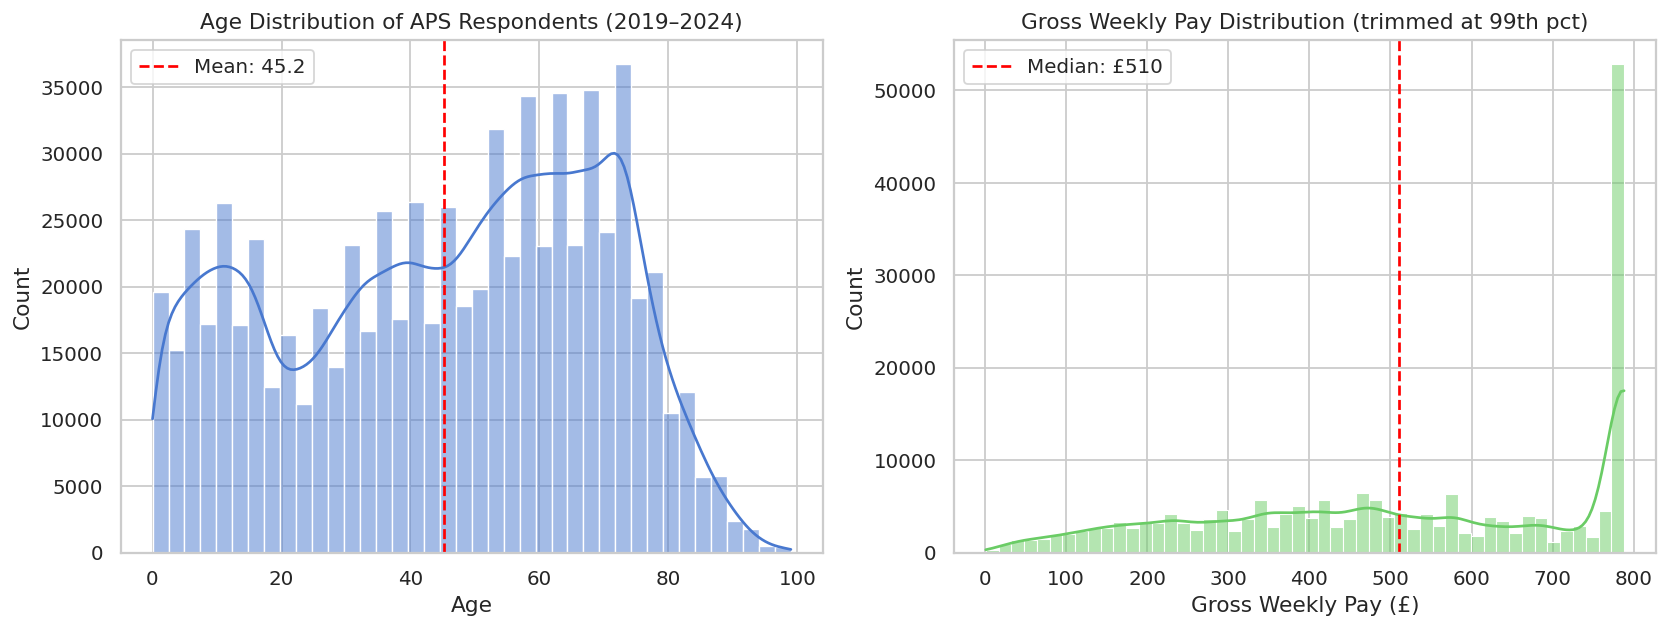

Saved → /home/squidnugi/comp3008-report/analysis_outputs/figures/eda1_distributions.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Age distribution ──────────────────────────────────────────────────────────
age = df["AGE"].dropna()
sns.histplot(age, bins=40, kde=True, ax=axes[0], color="#4878CF")
axes[0].set_title("Age Distribution of APS Respondents (2019–2024)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].axvline(age.mean(), color="red", linestyle="--", label=f"Mean: {age.mean():.1f}")
axes[0].legend()

# ── Gross weekly pay distribution (trimmed at 99th percentile to remove outliers)
pay = df["GROSS_WEEKLY_PAY"].dropna()
pay_trimmed = pay[pay <= pay.quantile(0.99)]
sns.histplot(pay_trimmed, bins=50, kde=True, ax=axes[1], color="#6ACC65")
axes[1].set_title("Gross Weekly Pay Distribution (trimmed at 99th pct)")
axes[1].set_xlabel("Gross Weekly Pay (£)")
axes[1].set_ylabel("Count")
axes[1].axvline(pay_trimmed.median(), color="red", linestyle="--",
                label=f"Median: £{pay_trimmed.median():.0f}")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "eda1_distributions.png", dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'eda1_distributions.png'}")

---
## Section 5 — EDA Method 2: Labour Status Time-Series (2019–2024)

**Why this method?**  
A grouped time-series plot shows *how the composition of employment changed  
year-by-year*, making the COVID shock (2020) and recovery (2021–2022) directly  
visible. `ILODEFR` (mapped here as `LABOUR_STATUS`) is the standard ILO  
definition of employment status used by the ONS.

**ILODEFR code meanings (from data dictionary):**  
1 = In employment, 2 = ILO unemployed, 3 = Economically inactive

> **Report link → Application of Methods:** Identify the 2020 dip in employment and  
> discuss how furlough may have affected the ILO classification.

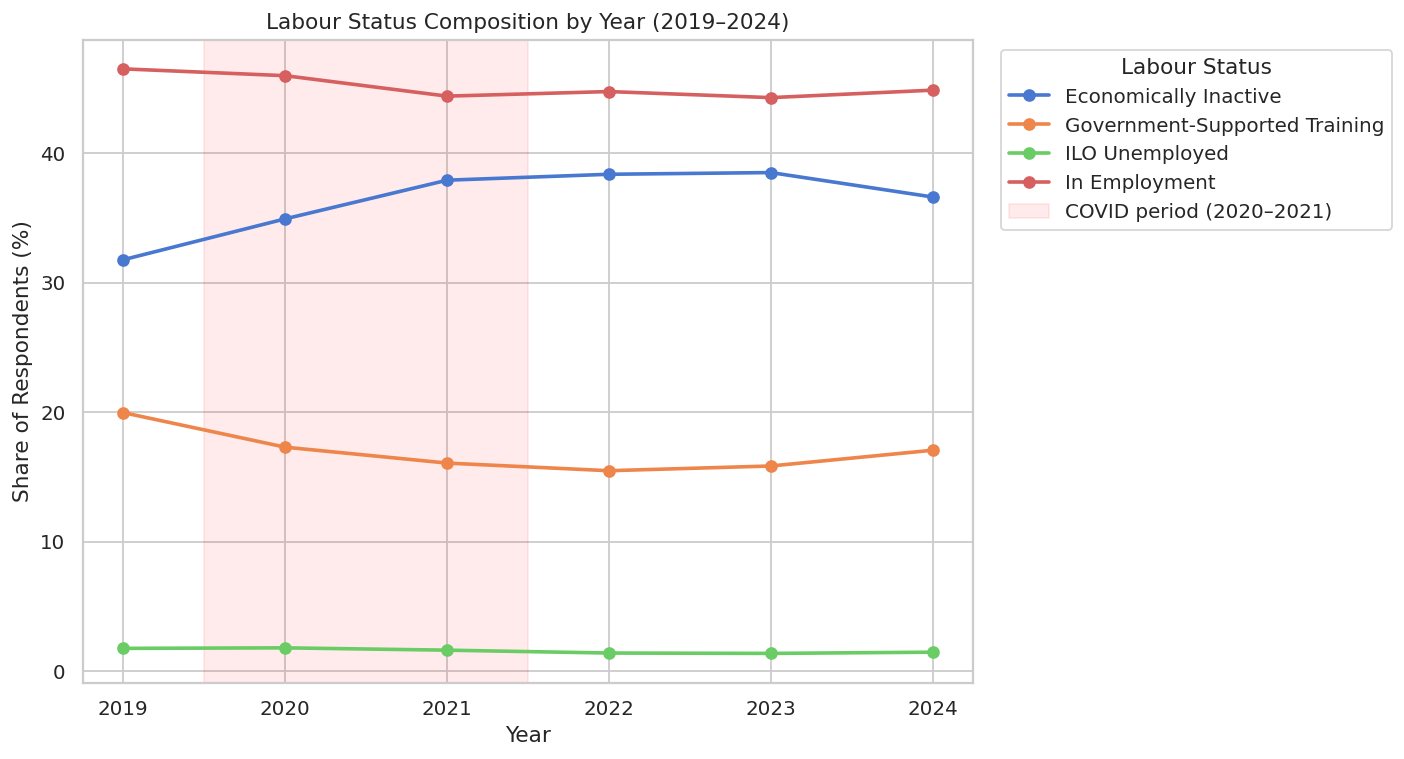

Saved → /home/squidnugi/comp3008-report/analysis_outputs/figures/eda2_labour_status_timeseries.png


In [8]:
# Recode numeric codes to readable labels for the chart
STATUS_LABELS = {
    "1": "In Employment",
    "2": "ILO Unemployed",
    "3": "Economically Inactive",
    "4": "Government-Supported Training",
}

ts = df.dropna(subset=["YEAR", "LABOUR_STATUS"]).copy()
ts["YEAR"] = ts["YEAR"].astype(int)
ts["STATUS_LABEL"] = ts["LABOUR_STATUS"].map(STATUS_LABELS).fillna("Other")

# Calculate percentage share of each status per year
grouped = (
    ts.groupby(["YEAR", "STATUS_LABEL"])
    .size()
    .reset_index(name="count")
)
totals = grouped.groupby("YEAR")["count"].transform("sum")
grouped["pct"] = 100 * grouped["count"] / totals

pivot = grouped.pivot(index="YEAR", columns="STATUS_LABEL", values="pct").fillna(0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
pivot.plot(ax=ax, marker="o", linewidth=2)
ax.axvspan(2019.5, 2021.5, alpha=0.08, color="red", label="COVID period (2020–2021)")
ax.set_title("Labour Status Composition by Year (2019–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Respondents (%)")
ax.set_xticks(sorted(ts["YEAR"].unique()))
ax.legend(title="Labour Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIG_DIR / "eda2_labour_status_timeseries.png", dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'eda2_labour_status_timeseries.png'}")

---
## Section 6 — EDA Method 3: Regional Comparison

**Why this method?**  
COVID's economic impact was not uniform across UK regions.  
A regional comparison reveals which Government Office Regions (GORs)  
experienced the greatest employment rate drops and slowest recoveries,  
directly addressing the *regional economies* component of the research question.

> **Report link → Application of Methods:** Compare London vs. the North to discuss  
> structural differences in regional labour markets.

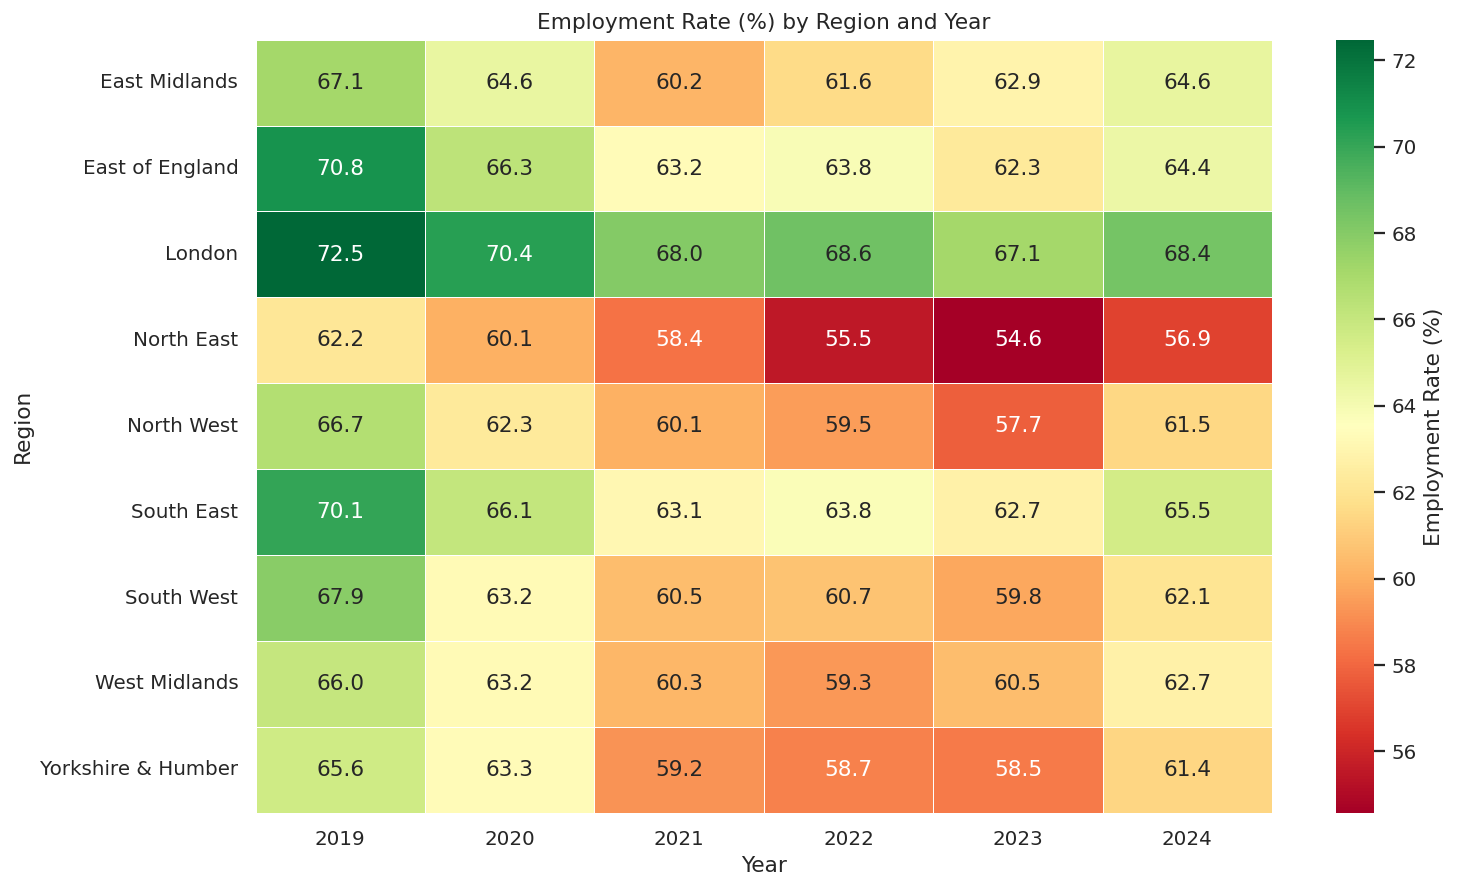

Saved → /home/squidnugi/comp3008-report/analysis_outputs/figures/eda3_regional_employment_heatmap.png


In [9]:
# GOR9D region codes (England + Wales + Scotland + NI)
REGION_NAMES = {
    "E12000001": "North East",
    "E12000002": "North West",
    "E12000003": "Yorkshire & Humber",
    "E12000004": "East Midlands",
    "E12000005": "West Midlands",
    "E12000006": "East of England",
    "E12000007": "London",
    "E12000008": "South East",
    "E12000009": "South West",
    "W92000004": "Wales",
    "S92000003": "Scotland",
    "N92000002": "Northern Ireland",
}

reg = df.dropna(subset=["YEAR", "REGION_CODE", "LABOUR_STATUS"]).copy()
reg["YEAR"] = reg["YEAR"].astype(int)
reg["REGION_NAME"] = reg["REGION_CODE"].map(REGION_NAMES)

# Employment rate = proportion of respondents coded as 'In Employment' (ILODEFR = 1)
reg["EMPLOYED"] = reg["LABOUR_STATUS"].isin(["1", "4"]).astype(int)

emp_rate = (
    reg.groupby(["YEAR", "REGION_NAME"])["EMPLOYED"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"EMPLOYED": "Employment Rate (%)"})
)

# ── Heatmap: regions × years ───────────────────────────────────────────────────
pivot_reg = emp_rate.pivot(index="REGION_NAME", columns="YEAR", values="Employment Rate (%)")

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot_reg,
    annot=True, fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Employment Rate (%)"},
)
ax.set_title("Employment Rate (%) by Region and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Region")
plt.tight_layout()
fig.savefig(FIG_DIR / "eda3_regional_employment_heatmap.png", dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'eda3_regional_employment_heatmap.png'}")

---
## Section 7 — EDA Method 4: K-Means Clustering of Worker Profiles

**Why this method?**  
K-Means clustering is an unsupervised method that groups respondents by  
numerical similarity (age, pay, hours). It reveals distinct worker *profiles*  
without assuming categories in advance — useful for checking whether  
COVID affected some clusters more than others.  
PCA is used only to visualise the 5-dimensional cluster space in 2D.

> **Report link → Application of Methods:** Describe each cluster by its centroid  
> values. Discuss whether cluster membership shifted between 2019 and 2021.

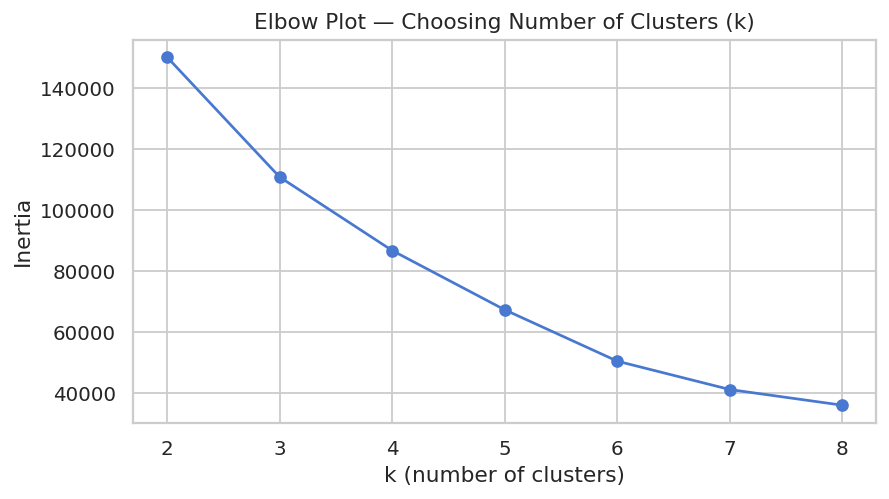

Choose k at the 'elbow' — the point where inertia stops decreasing steeply.


In [10]:
# Features for clustering — only numeric, employment-relevant variables
CLUSTER_FEATURES = ["AGE", "WEIGHT", "GROSS_WEEKLY_PAY", "HOURLY_RATE"]

cluster_work = df[CLUSTER_FEATURES].apply(pd.to_numeric, errors="coerce")

# Use a random sample for speed — 50,000 rows is representative of 750k
sample_n = min(50_000, len(cluster_work))
cluster_sample = cluster_work.sample(n=sample_n, random_state=42)

# ── Elbow method to choose k ───────────────────────────────────────────────────
imputer = SimpleImputer(strategy="median")   # fill missing values with median
scaler  = StandardScaler()                   # standardise so large-scale pay doesn't dominate

X = scaler.fit_transform(imputer.fit_transform(cluster_sample))

inertias = []
K_RANGE  = range(2, 9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_RANGE), inertias, marker="o")
ax.set_title("Elbow Plot — Choosing Number of Clusters (k)")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Inertia")
plt.tight_layout()
fig.savefig(FIG_DIR / "eda4a_elbow.png", dpi=150)
plt.show()
print("Choose k at the 'elbow' — the point where inertia stops decreasing steeply.")

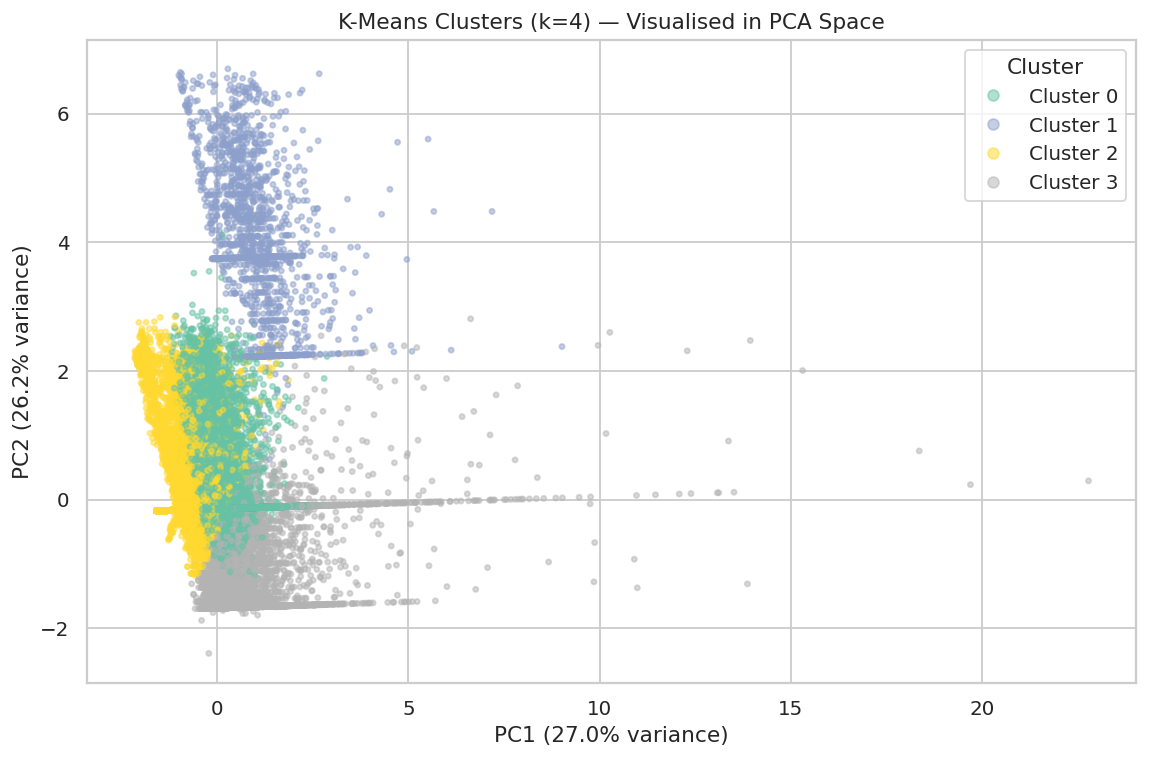


Cluster centroids (original scale):


,AGE,WEIGHT,GROSS_WEEKLY_PAY,HOURLY_RATE
Cluster,,,,
0,64.70,129.09,354.50,11.30
1,45.87,181.70,456.54,79.87
2,18.23,37.21,359.26,10.04
3,42.63,474.82,736.33,17.41


In [11]:
# ── Fit final KMeans with chosen k ────────────────────────────────────────────
# Change K_CHOSEN here if your elbow plot suggests a different value.
K_CHOSEN = 4

kmeans = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# ── Reduce to 2D with PCA for visualisation only ───────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="Set2", s=8, alpha=0.5)
ax.set_title(f"K-Means Clusters (k={K_CHOSEN}) — Visualised in PCA Space")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [f"Cluster {i}" for i in range(K_CHOSEN)],
          title="Cluster", loc="best")
plt.tight_layout()
fig.savefig(FIG_DIR / "eda4b_kmeans_pca.png", dpi=150)
plt.show()

# ── Cluster profile summary ───────────────────────────────────────────────────
# Shows the mean of each feature per cluster — helps interpret what each group represents.
cluster_sample_with_labels = cluster_sample.copy()
cluster_sample_with_labels["Cluster"] = labels
print("\nCluster centroids (original scale):")
cluster_sample_with_labels.groupby("Cluster").mean().round(2)

---
## Section 8 — Predictive Method 1: ARIMA Time-Series Forecast

**Why ARIMA?**  
ARIMA (AutoRegressive Integrated Moving Average) models temporal autocorrelation  
in a sequence of observations. Annual employment rate is a univariate time series  
where past values predict future values — a natural ARIMA use case.  
The model is trained on 2019–2022 and tested on 2023–2024.

**Limitation to discuss in report:**  
Only six annual data points (2019–2024) are available. ARIMA requires a longer  
series for reliable parameter estimation. Results should be treated as indicative  
rather than definitive forecasts.

> **Report link → Application of Methods + Results:** Quantify MAE and discuss  
> whether the model captured the post-COVID recovery trend.

Annual employment rate series:
YEAR
2019    66.46
2020    63.27
2021    60.46
2022    60.23
2023    60.12
2024    61.92

Selected ARIMA order: (0, 0, 0)
ARIMA MAE on test set: 1.585 percentage points


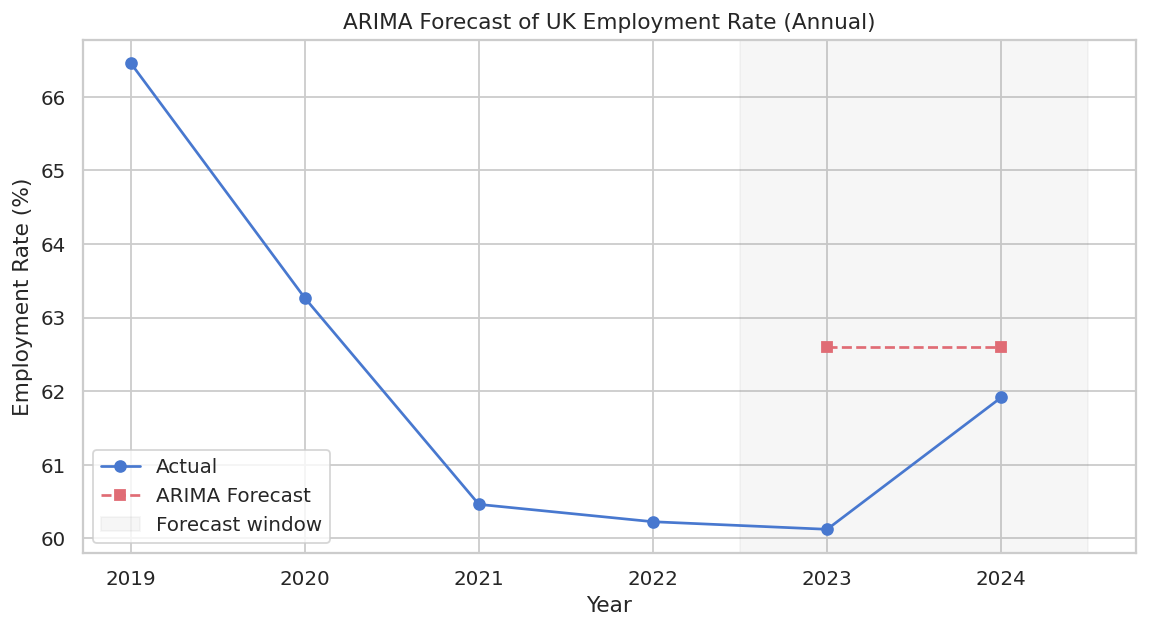

Saved → /home/squidnugi/comp3008-report/analysis_outputs/figures/model1_arima_forecast.png


In [12]:
if not ARIMA_AVAILABLE:
    print("Skipping ARIMA — install pmdarima first: pip install pmdarima")
else:
    # Aggregate to annual employment rate — one value per year
    arima_df = df.dropna(subset=["YEAR", "LABOUR_STATUS"]).copy()
    arima_df["YEAR"]     = arima_df["YEAR"].astype(int)
    arima_df["EMPLOYED"] = arima_df["LABOUR_STATUS"].isin(["1", "4"]).astype(int)

    annual_emp = (
        arima_df.groupby("YEAR")["EMPLOYED"]
        .mean()
        .mul(100)
        .sort_index()
    )

    print("Annual employment rate series:")
    print(annual_emp.round(2).to_string())

    # ── Train/test split ──────────────────────────────────────────────────────
    # Train: 2019–2022 (4 points) | Test: 2023–2024 (2 points)
    train_ts = annual_emp[annual_emp.index <= 2022]
    test_ts  = annual_emp[annual_emp.index >= 2023]

    # auto_arima automatically selects the best (p,d,q) order using AIC
    model = auto_arima(
        train_ts,
        seasonal=False,        # no seasonal component with annual data
        stepwise=True,         # faster search
        suppress_warnings=True,
        error_action="ignore",
    )
    print(f"\nSelected ARIMA order: {model.order}")

    forecast = model.predict(n_periods=len(test_ts))
    arima_mae = mean_absolute_error(test_ts, forecast)
    print(f"ARIMA MAE on test set: {arima_mae:.3f} percentage points")

    # ── Plot forecast vs actual ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(annual_emp.index, annual_emp.values, marker="o", label="Actual", color="#4878CF")
    ax.plot(test_ts.index, forecast, marker="s", linestyle="--",
            label="ARIMA Forecast", color="#E06C75")
    ax.axvspan(2022.5, 2024.5, alpha=0.07, color="grey", label="Forecast window")
    ax.set_title("ARIMA Forecast of UK Employment Rate (Annual)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Employment Rate (%)")
    ax.set_xticks(list(annual_emp.index))
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIG_DIR / "model1_arima_forecast.png", dpi=150)
    plt.show()
    print(f"Saved → {FIG_DIR / 'model1_arima_forecast.png'}")

---
## Section 9 — Predictive Method 2: Ridge Regression (Gross Weekly Pay)

**Why Ridge Regression?**  
Ridge is a regularised linear model that is interpretable and serves as a  
strong baseline against which the Random Forest can be compared.  
Predicting gross weekly pay from demographic and regional features  
quantifies wage inequality — relevant to COVID's unequal economic impact.

**Assumption:** Pay is approximately linearly related to age, qualification,  
and region — an assumption the residual plot in Section 10 will test.

> **Report link → Results:** Report R², MAE, and RMSE. Discuss what a low R²  
> means given 72% missingness in GROSS_WEEKLY_PAY.

In [13]:
# ── Feature and target selection ───────────────────────────────────────────────
NUM_FEATURES = ["AGE", "YEAR", "WEIGHT"]
CAT_FEATURES = ["SEX", "HIGHEST_QUAL", "ETHNICITY", "COUNTRY_CODE",
                "REGION_CODE", "LABOUR_STATUS"]
TARGET       = "GROSS_WEEKLY_PAY"

model_df = df[NUM_FEATURES + CAT_FEATURES + [TARGET]].copy()
model_df[TARGET] = pd.to_numeric(model_df[TARGET], errors="coerce")
model_df = model_df.dropna(subset=[TARGET])

# Trim top and bottom 1% to reduce influence of data-entry outliers
lo, hi = model_df[TARGET].quantile([0.01, 0.99])
model_df = model_df[(model_df[TARGET] >= lo) & (model_df[TARGET] <= hi)]

print(f"Rows available for regression: {len(model_df):,}")
print(f"Target range after trimming: £{lo:.2f} – £{hi:.2f}")

# ── Time-aware train/test split ────────────────────────────────────────────────
# Train on 2019–2023 | Test on 2024 (mimics real forecasting scenario)
train = model_df[model_df["YEAR"] <= 2023]
test  = model_df[model_df["YEAR"] == 2024]

# Fallback: if 2024 has no pay data, use last 20% of data as test
if len(test) < 100:
    split_year = model_df["YEAR"].quantile(0.8)
    train = model_df[model_df["YEAR"] <= split_year]
    test  = model_df[model_df["YEAR"] >  split_year]
    print(f"Fallback split used: train ≤ {split_year}, test > {split_year}")

X_train = train[NUM_FEATURES + CAT_FEATURES]
y_train = train[TARGET]
X_test  = test[NUM_FEATURES + CAT_FEATURES]
y_test  = test[TARGET]

print(f"\nTrain rows: {len(X_train):,} | Test rows: {len(X_test):,}")

Rows available for regression: 207,735
Target range after trimming: £43.00 – £788.00

Train rows: 174,079 | Test rows: 33,656


In [14]:
# ── Build and fit the Ridge pipeline ──────────────────────────────────────────
def build_reg_pipeline(model) -> Pipeline:
    """Wrap a regressor in an impute → encode → scale → model pipeline."""
    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),   # fill numeric NaN with median
        ("scale",  StandardScaler()),                   # z-score normalisation
    ])
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),   # fill categorical NaN
        ("encode", OneHotEncoder(handle_unknown="ignore")),    # dummy encode
    ])
    pre = ColumnTransformer([
        ("num", num_pipe, NUM_FEATURES),
        ("cat", cat_pipe, CAT_FEATURES),
    ])
    return Pipeline([("pre", pre), ("model", model)])

ridge_pipe = build_reg_pipeline(Ridge(alpha=1.0))

# Convert pandas nullable NA to numpy NaN for sklearn compatibility
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
for col in CAT_FEATURES:
    X_train_clean[col] = X_train_clean[col].astype("object").replace({pd.NA: np.nan})
    X_test_clean[col] = X_test_clean[col].astype("object").replace({pd.NA: np.nan})

ridge_pipe.fit(X_train_clean, y_train)

pred_ridge = ridge_pipe.predict(X_test_clean)

ridge_metrics = {
    "MAE":  mean_absolute_error(y_test, pred_ridge),
    "RMSE": np.sqrt(mean_squared_error(y_test, pred_ridge)),
    "R2":   r2_score(y_test, pred_ridge),
}
print("Ridge Regression metrics:")
for k, v in ridge_metrics.items():
    print(f"  {k}: {v:.4f}")

Ridge Regression metrics:
  MAE: 157.6906
  RMSE: 193.7448
  R2: 0.2177


---
## Section 10 — Predictive Method 3: Random Forest Regressor

**Why Random Forest?**  
Random Forest captures non-linear relationships (e.g. pay rising steeply  
with age until a mid-career peak then plateauing) that Ridge cannot model.  
Comparing the two quantifies how much non-linearity exists in the wage data.

**Suitability note for report:** Random Forest is computationally expensive  
and less interpretable than Ridge, but provides feature importance scores  
that show which factors most predict pay — directly useful for policy discussion.

> **Report link → Results:** Discuss the feature importance chart and compare  
> R² and RMSE between Ridge and Random Forest.

In [15]:
# Cap training rows for speed — 200k is representative and trains in ~1–2 minutes
MAX_TRAIN = 200_000

# Convert pandas nullable NA to numpy NaN for sklearn compatibility
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
for col in CAT_FEATURES:
    X_train_rf[col] = X_train_rf[col].astype("object").replace({pd.NA: np.nan})
    X_test_rf[col] = X_test_rf[col].astype("object").replace({pd.NA: np.nan})

if len(X_train_rf) > MAX_TRAIN:
    X_tr_sub = X_train_rf.sample(n=MAX_TRAIN, random_state=42)
    y_tr_sub = y_train.loc[X_tr_sub.index]
else:
    X_tr_sub, y_tr_sub = X_train_rf, y_train

rf_pipe = build_reg_pipeline(
    RandomForestRegressor(
        n_estimators=100,      # 100 trees — good balance of speed vs accuracy
        max_depth=15,          # limit depth to reduce overfitting
        min_samples_leaf=5,    # each leaf must have ≥5 samples
        random_state=42,
        n_jobs=-1,             # use all CPU cores
    )
)
rf_pipe.fit(X_tr_sub, y_tr_sub)

pred_rf = rf_pipe.predict(X_test_rf)

rf_metrics = {
    "MAE":  mean_absolute_error(y_test, pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test, pred_rf)),
    "R2":   r2_score(y_test, pred_rf),
}
print("Random Forest metrics:")
for k, v in rf_metrics.items():
    print(f"  {k}: {v:.4f}")

Random Forest metrics:
  MAE: 149.4760
  RMSE: 182.6520
  R2: 0.3047


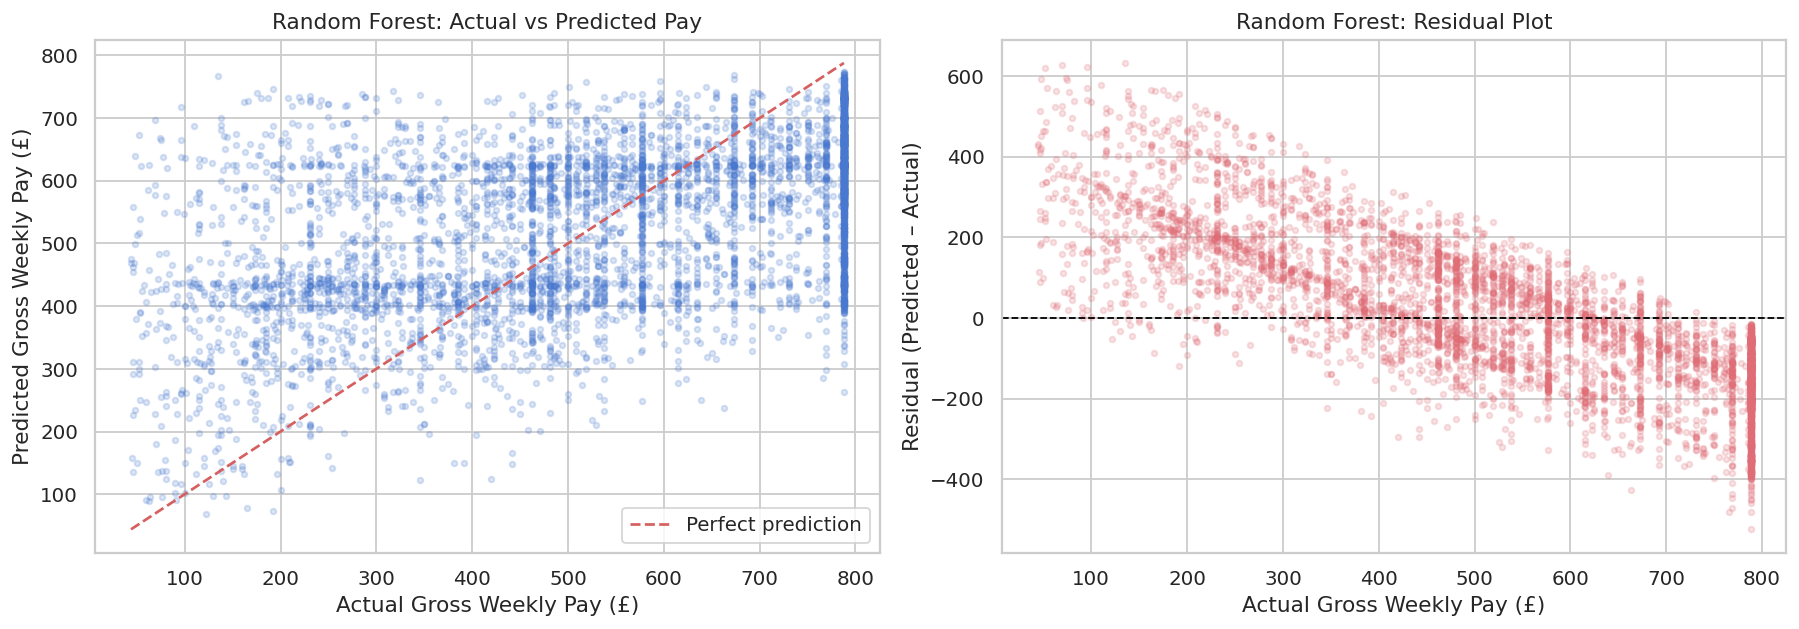

Saved → /home/squidnugi/comp3008-report/analysis_outputs/figures/model3_rf_actual_vs_predicted.png


In [16]:
# ── Actual vs Predicted scatter (best model) ───────────────────────────────────
rng = np.random.default_rng(42)
plot_idx = rng.choice(len(y_test), size=min(6000, len(y_test)), replace=False)
y_plot = np.array(y_test.iloc[plot_idx])
p_plot = pred_rf[plot_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_plot, p_plot, alpha=0.2, s=10, color="#4878CF")
lim = [min(y_plot.min(), p_plot.min()), max(y_plot.max(), p_plot.max())]
axes[0].plot(lim, lim, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Gross Weekly Pay (£)")
axes[0].set_ylabel("Predicted Gross Weekly Pay (£)")
axes[0].set_title("Random Forest: Actual vs Predicted Pay")
axes[0].legend()

# Residuals
residuals = p_plot - y_plot
axes[1].scatter(y_plot, residuals, alpha=0.2, s=10, color="#E06C75")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Actual Gross Weekly Pay (£)")
axes[1].set_ylabel("Residual (Predicted – Actual)")
axes[1].set_title("Random Forest: Residual Plot")

plt.tight_layout()
fig.savefig(FIG_DIR / "model3_rf_actual_vs_predicted.png", dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'model3_rf_actual_vs_predicted.png'}")

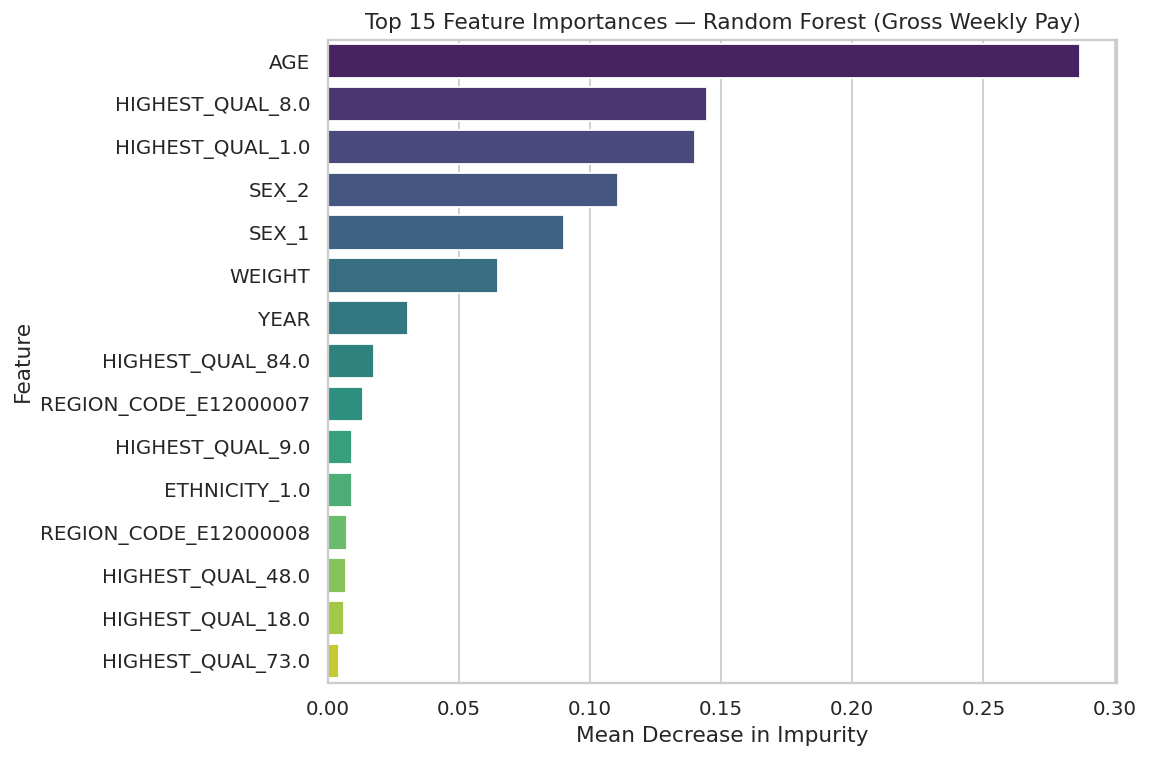

Saved → /home/squidnugi/comp3008-report/analysis_outputs/figures/model3_rf_feature_importance.png


In [17]:
# ── Feature importance ────────────────────────────────────────────────────────
# Extract feature names after one-hot encoding
pre_step   = rf_pipe.named_steps["pre"]
cat_names  = pre_step.named_transformers_["cat"]["encode"].get_feature_names_out(CAT_FEATURES)
all_names  = NUM_FEATURES + list(cat_names)

importances = rf_pipe.named_steps["model"].feature_importances_
imp_df = (
    pd.DataFrame({"Feature": all_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .head(15)   # show top 15 most important features
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=imp_df, x="Importance", y="Feature", ax=ax, palette="viridis")
ax.set_title("Top 15 Feature Importances — Random Forest (Gross Weekly Pay)")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
fig.savefig(FIG_DIR / "model3_rf_feature_importance.png", dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'model3_rf_feature_importance.png'}")

---
## Section 11 — Model Comparison & Suitability

This section produces the summary table required by the brief's instruction to  
*'comment on suitability and accuracy of each predictive method'*.

> **Report link → Results:** Paste the table below into your Results section  
> and write one paragraph per model discussing the metrics.

In [18]:
rows = [
    {
        "Model":   "ARIMA",
        "Target":  "Annual employment rate (%)",
        "MAE":     f"{arima_mae:.3f} pp" if ARIMA_AVAILABLE else "N/A",
        "RMSE":    "N/A (univariate TS)",
        "R²":      "N/A (univariate TS)",
        "Suitability": "Appropriate for temporal trend; limited by small series (n=6).",
    },
    {
        "Model":   "Ridge Regression",
        "Target":  "Gross weekly pay (£)",
        "MAE":     f"£{ridge_metrics['MAE']:.2f}",
        "RMSE":    f"£{ridge_metrics['RMSE']:.2f}",
        "R²":      f"{ridge_metrics['R2']:.4f}",
        "Suitability": "Interpretable linear baseline; assumes linearity which may not hold.",
    },
    {
        "Model":   "Random Forest",
        "Target":  "Gross weekly pay (£)",
        "MAE":     f"£{rf_metrics['MAE']:.2f}",
        "RMSE":    f"£{rf_metrics['RMSE']:.2f}",
        "R²":      f"{rf_metrics['R2']:.4f}",
        "Suitability": "Captures non-linear patterns; less interpretable, higher compute cost.",
    },
]

comparison_df = pd.DataFrame(rows).set_index("Model")
comparison_df.to_csv(OUT_DIR / "model_comparison.csv")
print("Model Comparison Table:")
comparison_df

Model Comparison Table:


,Target,MAE,RMSE,R²,Suitability
Model,,,,,
ARIMA,Annual employment rate (%),1.585 pp,N/A (univariate TS),N/A (univariate TS),Appropriate for temporal trend; limited by sma...
Ridge Regression,Gross weekly pay (£),£157.69,£193.74,0.2177,Interpretable linear baseline; assumes lineari...
Random Forest,Gross weekly pay (£),£149.48,£182.65,0.3047,Captures non-linear patterns; less interpretab...


---
## End of Notebook

All figures are saved to `analysis_outputs/figures/`.  
The model comparison table is saved to `analysis_outputs/model_comparison.csv`.

### Quick checklist before submitting
- [ ] Run all cells top-to-bottom (`Kernel → Restart & Run All`) with no errors
- [ ] All figures visible at 100% zoom in the report PDF
- [ ] ARIMA order noted in the report (printed in Section 8)
- [ ] Model comparison table included in Results section
- [ ] AI declaration completed in Appendix A
- [ ] This notebook included as Appendix B